In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


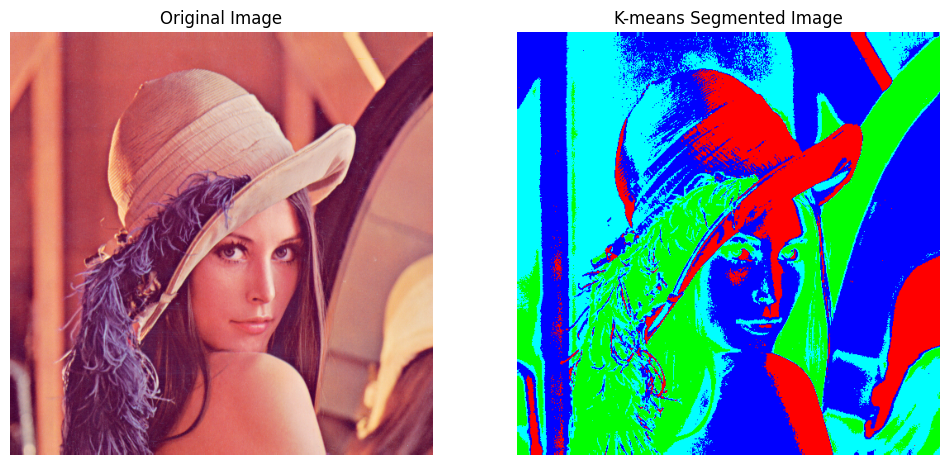

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
src_image = cv2.imread('lena.bmp')
if src_image is None:
    print("Could not load image...")
    exit()

# 将图像从BGR转换为RGB，适配matplotlib的颜色格式
src_image_rgb = cv2.cvtColor(src_image, cv2.COLOR_BGR2RGB)

# 设置颜色表（聚类后的颜色将随机从这里面选择）
color_tab = [
    [0, 0, 255],     # Red
    [0, 255, 0],     # Green
    [255, 0, 0],     # Blue
    [0, 255, 255],   # Yellow
    [255, 0, 255]    # Magenta
]

# 获取图像尺寸和通道信息
height, width, channels = src_image.shape
sample_count = width * height   # 总像素数
cluster_count = 4           # 设置聚类数量

# 将图像数据转换为K-means所需的二维数据结构
points = src_image.reshape(-1, 3).astype(np.float32)

# 设置K-means聚类参数
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 0.1)
ret, labels, centers = cv2.kmeans(points, cluster_count, None, criteria, 3, cv2.KMEANS_PP_CENTERS)

# 将标签转换为指定颜色表中的颜色
segmented_image = np.zeros_like(points)
for i in range(cluster_count):
    segmented_image[labels.flatten() == i] = color_tab[i]

# 将图像形状恢复为原始尺寸
segmented_image = segmented_image.reshape(src_image.shape)

# 使用matplotlib显示原始图像和分割后的图像
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(src_image_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("K-means Segmented Image")
plt.imshow(segmented_image)
plt.axis("off")

plt.show()
